# 🎯 Support Vector Machine (SVM) - Complete Learning Guide

## Overview
Support Vector Machines are powerful supervised learning algorithms used for classification and regression. They work by finding the optimal hyperplane that maximizes the margin between classes.

## Key Topics Covered:
1. **Fundamentals** - Core SVM concepts and mathematics
2. **Kernel Methods** - Linear, RBF, Polynomial, Sigmoid kernels
3. **Binary Classification** - Two-class classification problems
4. **Multi-class Classification** - One-vs-Rest and One-vs-One strategies
5. **Hyperparameter Tuning** - C and gamma optimization
6. **Real-world Applications** - Practical examples
7. **Advantages & Disadvantages** - When to use SVM

---

## References:
- [scikit-learn SVM Documentation](https://scikit-learn.org/stable/modules/svm.html)
- [Support Vector Machines - Wikipedia](https://en.wikipedia.org/wiki/Support_vector_machine)
- [SVM Tutorial - StatQuest](https://www.youtube.com/watch?v=efR1C6CvhmE)

## 📚 Section 1: Import Libraries

In [17]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, SVR
from sklearn.datasets import make_circles, make_moons, load_iris, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🧠 Section 2: SVM Fundamentals

### What is SVM?
SVM finds the optimal hyperplane (decision boundary) that:
1. Correctly separates classes
2. Maximizes the **margin** (distance between hyperplane and nearest data points)
3. Minimizes classification errors

### Key Concepts:
- **Hyperplane**: Decision boundary in n-dimensional space
- **Support Vectors**: Data points closest to the hyperplane
- **Margin**: Distance between hyperplane and support vectors
- **Kernel**: Function that transforms data to higher dimensions
- **C Parameter**: Trade-off between margin size and misclassification


🔷 EXAMPLE 1: Linear SVM (Linearly Separable Data)

✅ Model Performance:
  Accuracy: 1.0000
  Support Vectors: 3 out of 80


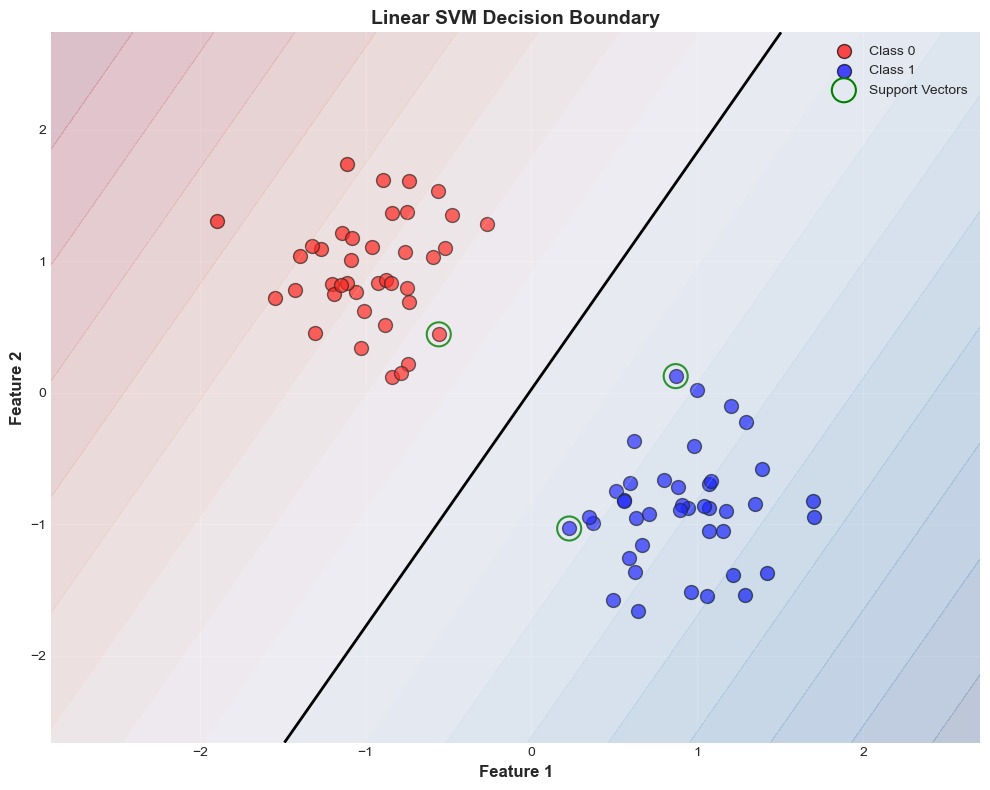


📊 Decision Function Analysis:
  Hyperplane equation: w·x + b = 0
  Coefficients (w): [ 1.22765547 -0.68089373]
  Intercept (b): 0.0179
  Margin width: 1.4247


In [18]:
# Example 1: Simple 2D Linearly Separable Data
print("\n" + "="*70)
print("🔷 EXAMPLE 1: Linear SVM (Linearly Separable Data)")
print("="*70)

# Create synthetic data
from sklearn.datasets import make_blobs
X_linear, y_linear = make_blobs(n_samples=100, centers=2, n_features=2, 
                                 random_state=42, cluster_std=1.5)

# Split data
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

# Scale data
scaler_lin = StandardScaler()
X_train_lin_scaled = scaler_lin.fit_transform(X_train_lin)
X_test_lin_scaled = scaler_lin.transform(X_test_lin)

# Train linear SVM
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_lin_scaled, y_train_lin)

# Predictions
y_pred_lin = svm_linear.predict(X_test_lin_scaled)
accuracy_lin = accuracy_score(y_test_lin, y_pred_lin)

print(f"\n✅ Model Performance:")
print(f"  Accuracy: {accuracy_lin:.4f}")
print(f"  Support Vectors: {len(svm_linear.support_vectors_)} out of {len(X_train_lin_scaled)}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot data points
colors = ['red', 'blue']
for i, (color, label) in enumerate(zip(colors, [0, 1])):
    mask = y_train_lin == label
    ax.scatter(X_train_lin_scaled[mask, 0], X_train_lin_scaled[mask, 1],
              c=color, label=f'Class {label}', s=100, alpha=0.7, edgecolors='k')

# Plot support vectors
ax.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1],
          s=300, linewidth=1.5, facecolors='none', edgecolors='green', label='Support Vectors')

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(X_train_lin_scaled[:, 0].min() - 1, X_train_lin_scaled[:, 0].max() + 1, 100),
                      np.linspace(X_train_lin_scaled[:, 1].min() - 1, X_train_lin_scaled[:, 1].max() + 1, 100))
Z = svm_linear.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black', linestyles='solid')
ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.2)

ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
ax.set_title('Linear SVM Decision Boundary', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Decision Function Analysis:")
print(f"  Hyperplane equation: w·x + b = 0")
print(f"  Coefficients (w): {svm_linear.coef_[0]}")
print(f"  Intercept (b): {svm_linear.intercept_[0]:.4f}")
print(f"  Margin width: {2 / np.linalg.norm(svm_linear.coef_[0]):.4f}")

## 🎨 Section 3: Kernel Methods

### Kernel Types:
1. **Linear**: Best for linearly separable data
2. **RBF (Radial Basis Function)**: Non-linear, maps to infinite dimensions
3. **Polynomial**: Creates polynomial decision boundaries
4. **Sigmoid**: Similar to neural networks

Each kernel has different computational complexity and works better for different data types.


🔶 EXAMPLE 2: Comparing Different Kernels


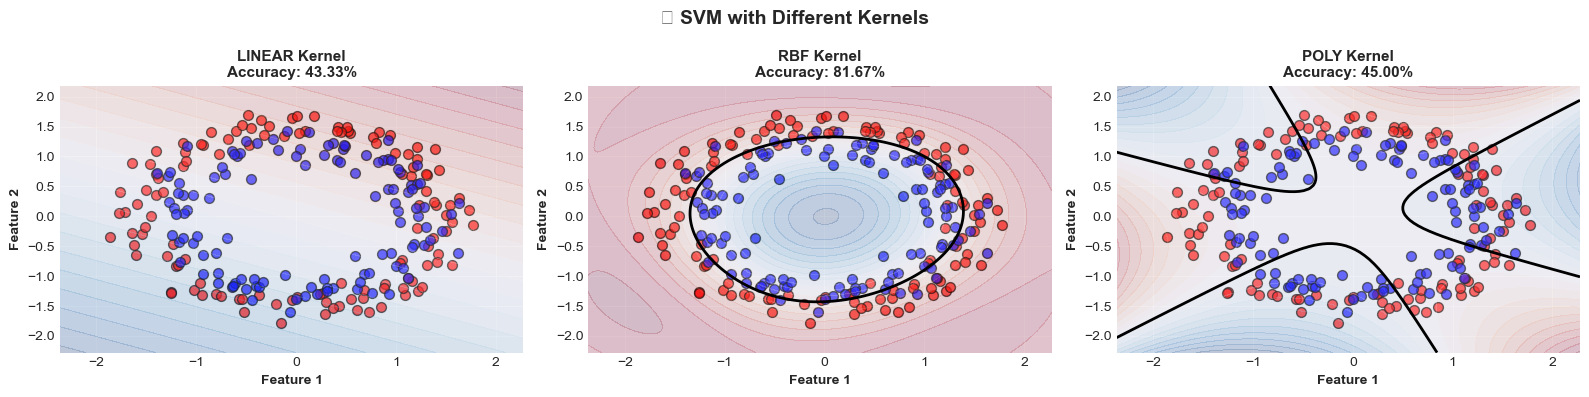


📊 Kernel Comparison:
  LINEAR    : 0.4333
  RBF       : 0.8167
  POLY      : 0.4500


In [19]:
# Example 2: Non-linear Data - Comparing Kernels
print("\n" + "="*70)
print("🔶 EXAMPLE 2: Comparing Different Kernels")
print("="*70)

# Create non-linearly separable data
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, random_state=42)

# Scale data
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circles_scaled, y_circles, test_size=0.2, random_state=42
)

# Test different kernels
kernels = ['linear', 'rbf', 'poly']
results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('🎨 SVM with Different Kernels', fontsize=14, fontweight='bold')

for idx, kernel in enumerate(kernels):
    # Create and train SVM
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
    else:
        svm = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    
    svm.fit(X_train_c, y_train_c)
    y_pred_c = svm.predict(X_test_c)
    
    acc = accuracy_score(y_test_c, y_pred_c)
    results[kernel] = acc
    
    # Plot
    ax = axes[idx]
    
    # Data points
    for i, (color, label) in enumerate(zip(['red', 'blue'], [0, 1])):
        mask = y_train_c == label
        ax.scatter(X_train_c[mask, 0], X_train_c[mask, 1],
                  c=color, label=f'Class {label}', s=50, alpha=0.7, edgecolors='k')
    
    # Decision boundary
    xx, yy = np.meshgrid(np.linspace(X_train_c[:, 0].min() - 0.5, X_train_c[:, 0].max() + 0.5, 100),
                          np.linspace(X_train_c[:, 1].min() - 0.5, X_train_c[:, 1].max() + 0.5, 100))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.2)
    
    ax.set_xlabel('Feature 1', fontsize=10, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=10, fontweight='bold')
    ax.set_title(f'{kernel.upper()} Kernel\nAccuracy: {acc:.2%}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Kernel Comparison:")
for kernel, acc in results.items():
    print(f"  {kernel.upper():10s}: {acc:.4f}")

## 🔴 Section 4: Binary Classification - Real Dataset

Using the Breast Cancer dataset to demonstrate binary classification with SVM.


🔴 EXAMPLE 3: Breast Cancer Classification

📊 Dataset Information:
  Samples: 569
  Features: 30
  Classes: Malignant (0) = 212, Benign (1) = 357

✅ Model Performance:
  Accuracy:  0.9561
  Precision: 0.9714
  Recall:    0.9577
  F1 Score:  0.9645
  ROC-AUC:   0.9934


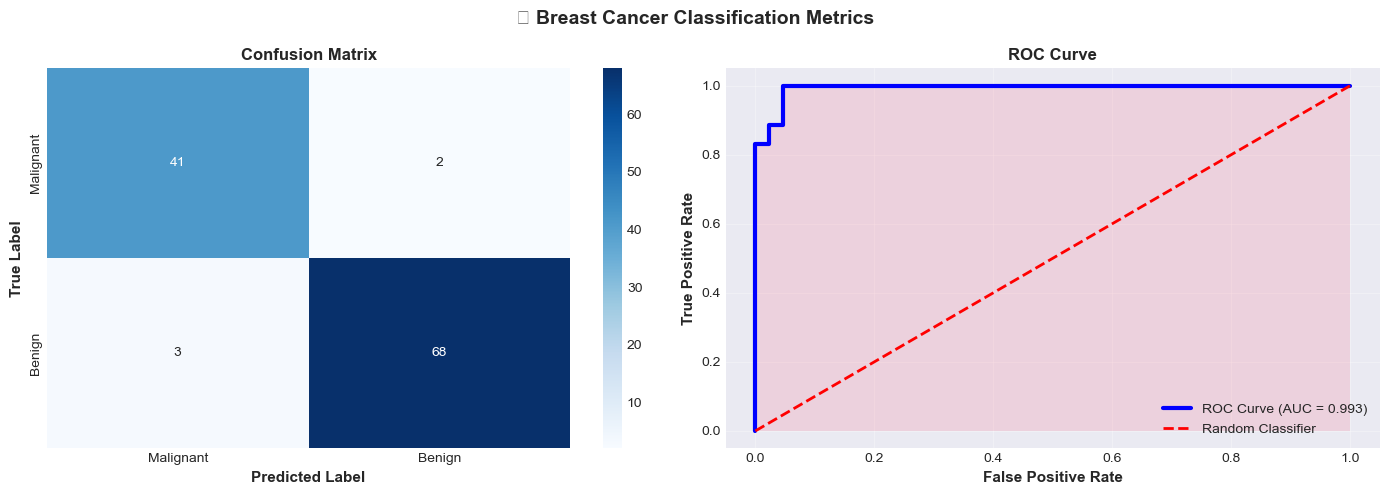

In [20]:
# Example 3: Breast Cancer Classification
print("\n" + "="*70)
print("🔴 EXAMPLE 3: Breast Cancer Classification")
print("="*70)

# Load dataset
cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target

print(f"\n📊 Dataset Information:")
print(f"  Samples: {X_cancer.shape[0]}")
print(f"  Features: {X_cancer.shape[1]}")
print(f"  Classes: Malignant (0) = {(y_cancer == 0).sum()}, Benign (1) = {(y_cancer == 1).sum()}")

# Split and scale
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

scaler_cancer = StandardScaler()
X_train_cancer_scaled = scaler_cancer.fit_transform(X_train_cancer)
X_test_cancer_scaled = scaler_cancer.transform(X_test_cancer)

# Train SVM with RBF kernel
svm_cancer = SVC(kernel='rbf', C=100, gamma=0.01, probability=True, random_state=42)
svm_cancer.fit(X_train_cancer_scaled, y_train_cancer)

# Predictions
y_pred_cancer = svm_cancer.predict(X_test_cancer_scaled)
y_pred_proba_cancer = svm_cancer.predict_proba(X_test_cancer_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test_cancer, y_pred_cancer)
precision = precision_score(y_test_cancer, y_pred_cancer)
recall = recall_score(y_test_cancer, y_pred_cancer)
f1 = f1_score(y_test_cancer, y_pred_cancer)
roc_auc = roc_auc_score(y_test_cancer, y_pred_proba_cancer)

print(f"\n✅ Model Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test_cancer, y_pred_cancer).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔴 Breast Cancer Classification Metrics', fontsize=14, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test_cancer, y_pred_cancer)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test_cancer, y_pred_proba_cancer)
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🌈 Section 5: Multi-class Classification

### Strategies:
- **One-vs-Rest (OvR)**: Trains one classifier per class vs all others
- **One-vs-One (OvO)**: Trains one classifier for each pair of classes

Using Iris dataset with 3 classes.


🌈 EXAMPLE 4: Multi-class Classification (Iris Dataset)

📊 Dataset Information:
  Samples: 150
  Features: 4
  Classes: 3 (Setosa, Versicolor, Virginica)

✅ Model Performance:
  Accuracy: 1.0000
  Support Vectors: 46 out of 120

📈 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



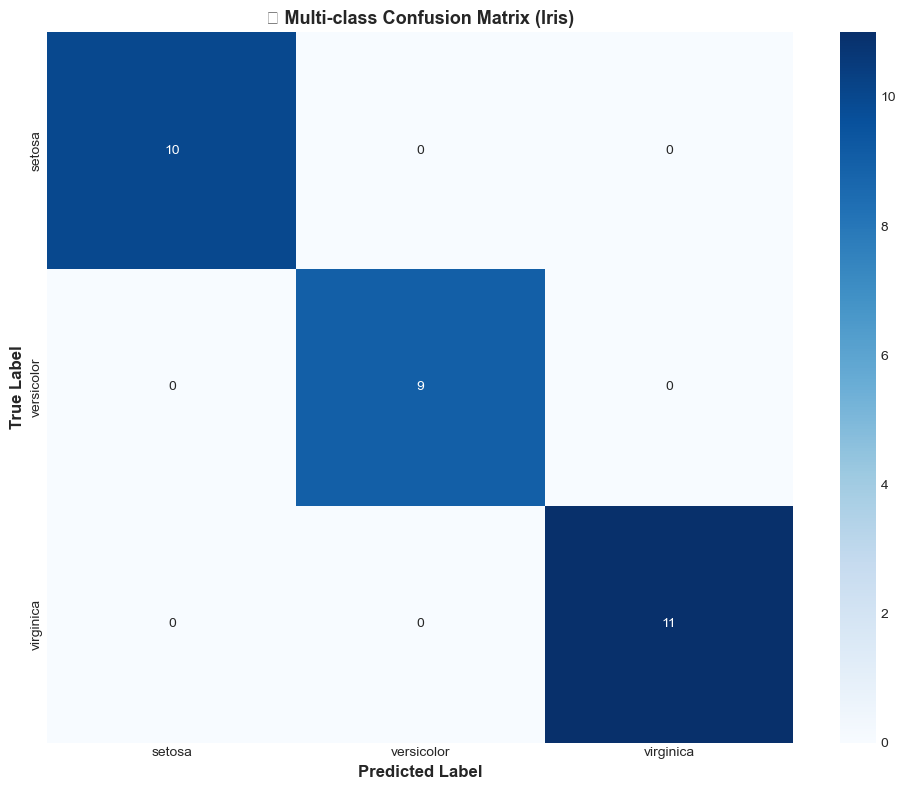

In [21]:
# Example 4: Multi-class Classification
print("\n" + "="*70)
print("🌈 EXAMPLE 4: Multi-class Classification (Iris Dataset)")
print("="*70)

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"\n📊 Dataset Information:")
print(f"  Samples: {X_iris.shape[0]}")
print(f"  Features: {X_iris.shape[1]}")
print(f"  Classes: {len(np.unique(y_iris))} (Setosa, Versicolor, Virginica)")

# Split and scale
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

# Train multi-class SVM
svm_iris = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_iris.fit(X_train_iris_scaled, y_train_iris)

# Predictions
y_pred_iris = svm_iris.predict(X_test_iris_scaled)

# Metrics
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)

print(f"\n✅ Model Performance:")
print(f"  Accuracy: {accuracy_iris:.4f}")
print(f"  Support Vectors: {len(svm_iris.support_vectors_)} out of {len(X_train_iris_scaled)}")

# Classification Report
print(f"\n📈 Classification Report:")
print(classification_report(y_test_iris, y_pred_iris, 
                          target_names=iris.target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title('🌈 Multi-class Confusion Matrix (Iris)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Section 6: Hyperparameter Tuning

### Key Parameters:
- **C**: Regularization parameter (trade-off margin vs misclassification)
  - Small C: Large margin, more misclassification
  - Large C: Small margin, fewer misclassification
- **gamma**: Kernel coefficient for RBF/Poly/Sigmoid
  - Small gamma: Each point has far reach
  - Large gamma: Each point has close reach


⚙️ EXAMPLE 5: Hyperparameter Tuning

🔍 Parameter Grid:
  C values: [0.1, 1, 10, 100]
  Gamma values: [0.001, 0.01, 0.1, 1]
  Kernels: ['rbf', 'poly']
  Total combinations: 32

⏳ Running GridSearchCV...

✅ Best Parameters Found:
  C: 100
  Gamma: 0.001
  Kernel: rbf
  Best CV Score: 0.9736

📊 Best Model Performance on Test Set:
  Accuracy: 0.9825

✅ Best Parameters Found:
  C: 100
  Gamma: 0.001
  Kernel: rbf
  Best CV Score: 0.9736

📊 Best Model Performance on Test Set:
  Accuracy: 0.9825


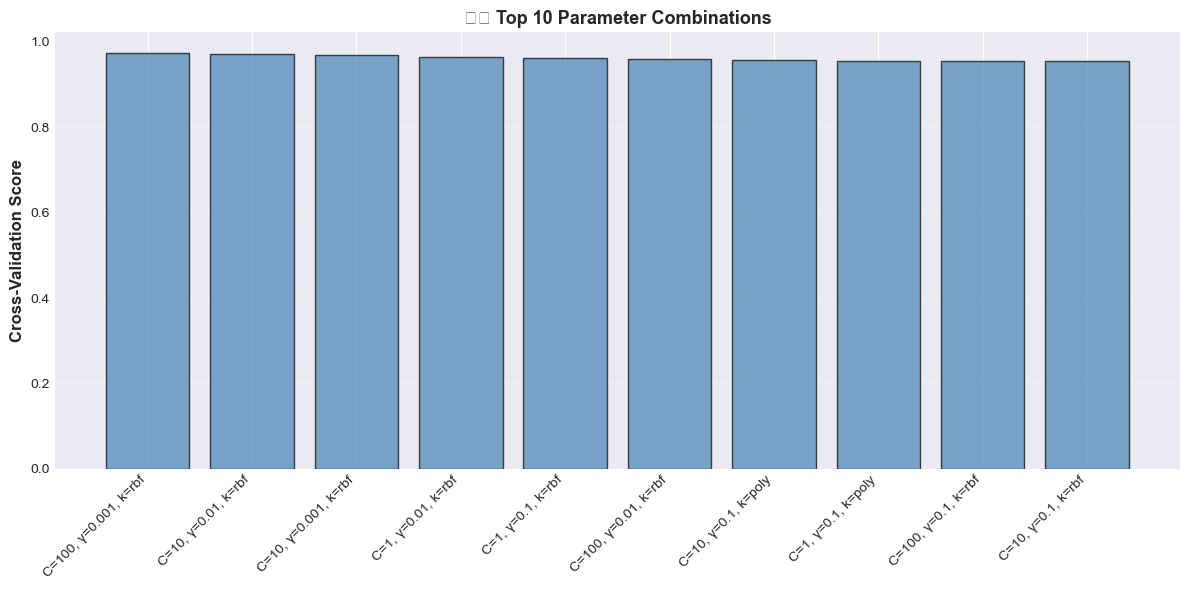

In [22]:
# Example 5: Hyperparameter Tuning with GridSearchCV
print("\n" + "="*70)
print("⚙️ EXAMPLE 5: Hyperparameter Tuning")
print("="*70)

# Use breast cancer dataset
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

print(f"\n🔍 Parameter Grid:")
print(f"  C values: {param_grid['C']}")
print(f"  Gamma values: {param_grid['gamma']}")
print(f"  Kernels: {param_grid['kernel']}")
print(f"  Total combinations: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])}")

print(f"\n⏳ Running GridSearchCV...")
grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, verbose=0)
grid_search.fit(X_train_cancer_scaled, y_train_cancer)

print(f"\n✅ Best Parameters Found:")
print(f"  C: {grid_search.best_params_['C']}")
print(f"  Gamma: {grid_search.best_params_['gamma']}")
print(f"  Kernel: {grid_search.best_params_['kernel']}")
print(f"  Best CV Score: {grid_search.best_score_:.4f}")

# Test best model
best_svm = grid_search.best_estimator_
y_pred_tuned = best_svm.predict(X_test_cancer_scaled)
accuracy_tuned = accuracy_score(y_test_cancer, y_pred_tuned)

print(f"\n📊 Best Model Performance on Test Set:")
print(f"  Accuracy: {accuracy_tuned:.4f}")

# Visualize parameter importance
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_10 = results_df.head(10)
x_pos = np.arange(len(top_10))
ax.bar(x_pos, top_10['mean_test_score'], color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"C={row['param_C']}, γ={row['param_gamma']}, k={row['param_kernel']}" 
                     for _, row in top_10.iterrows()], rotation=45, ha='right')
ax.set_ylabel('Cross-Validation Score', fontsize=12, fontweight='bold')
ax.set_title('⚙️ Top 10 Parameter Combinations', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 📊 Section 7: Feature Scaling Importance

SVMs are distance-based algorithms and are very sensitive to feature scaling. Unscaled features can significantly impact model performance.


📊 EXAMPLE 6: Feature Scaling Importance

📈 Comparison:
  Without Scaling: 0.6316
  With Scaling:    0.9561
  Improvement:     0.3246 (32.46%)


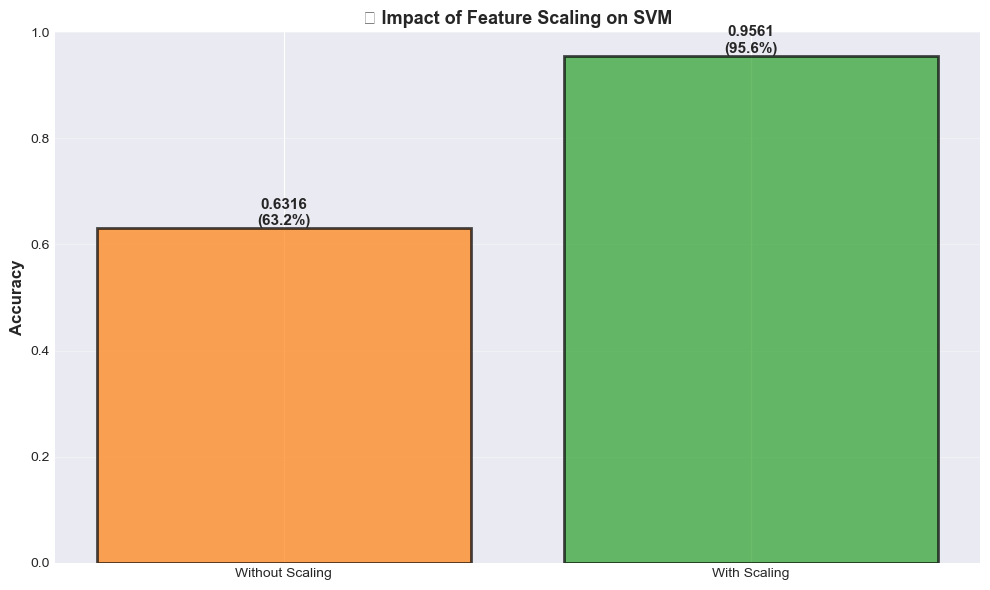

In [23]:
# Example 6: Feature Scaling Impact
print("\n" + "="*70)
print("📊 EXAMPLE 6: Feature Scaling Importance")
print("="*70)

# Train without scaling
svm_unscaled = SVC(kernel='rbf', C=100, gamma=0.01, random_state=42)
svm_unscaled.fit(X_train_cancer, y_train_cancer)
y_pred_unscaled = svm_unscaled.predict(X_test_cancer)
acc_unscaled = accuracy_score(y_test_cancer, y_pred_unscaled)

# Train with scaling
svm_scaled = SVC(kernel='rbf', C=100, gamma=0.01, random_state=42)
svm_scaled.fit(X_train_cancer_scaled, y_train_cancer)
y_pred_scaled = svm_scaled.predict(X_test_cancer_scaled)
acc_scaled = accuracy_score(y_test_cancer, y_pred_scaled)

print(f"\n📈 Comparison:")
print(f"  Without Scaling: {acc_unscaled:.4f}")
print(f"  With Scaling:    {acc_scaled:.4f}")
print(f"  Improvement:     {(acc_scaled - acc_unscaled):.4f} ({(acc_scaled - acc_unscaled)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Without Scaling', 'With Scaling']
accuracies = [acc_unscaled, acc_scaled]
colors = ['#ff7f0e', '#2ca02c']

bars = ax.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('📊 Impact of Feature Scaling on SVM', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}\n({acc*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 📋 Section 8: SVM Advantages & Disadvantages

### ✅ Advantages:
1. **Effective in high dimensions** - Works well with many features
2. **Memory efficient** - Uses support vectors only
3. **Versatile kernels** - Different kernels for different data types
4. **Good generalization** - Margin maximization reduces overfitting
5. **Works for binary and multi-class** - Scalable to multiple classes

### ❌ Disadvantages:
1. **Slow training on large datasets** - O(n²) or O(n³) complexity
2. **Hard to interpret** - Black box model
3. **Sensitive to feature scaling** - Must normalize features
4. **Parameter tuning required** - C and gamma need optimization
5. **Not ideal for very large datasets** - Better alternatives exist

### When to Use SVM:
- Medium-sized datasets (100 to 100,000 samples)
- High-dimensional data
- Binary classification problems
- When interpretability is not critical

In [24]:
# Example 7: Comparison Summary
print("\n" + "="*70)
print("📊 EXAMPLE 7: SVM Use Cases Summary")
print("="*70)

use_cases = {
    'Binary Classification': {
        'pros': ['Optimal decision boundary', 'Margin maximization', 'Good generalization'],
        'cons': ['Need balanced data', 'Requires scaling'],
        'best_kernel': 'RBF'
    },
    'High-Dimensional Data': {
        'pros': ['Handles 1000+ features', 'Curse of dimensionality resistant'],
        'cons': ['Slow training', 'Hard to interpret'],
        'best_kernel': 'RBF or Linear'
    },
    'Text Classification': {
        'pros': ['Excellent on text data', 'Linear kernel works well'],
        'cons': ['Large feature spaces', 'Slow with many samples'],
        'best_kernel': 'Linear'
    },
    'Image Classification': {
        'pros': ['Works with feature extraction', 'Margin concept works well'],
        'cons': ['Slow with raw pixels', 'Better deep learning alternatives'],
        'best_kernel': 'RBF'
    }
}

print("\n🎯 Use Case Analysis:\n")
for use_case, details in use_cases.items():
    print(f"  {use_case}:")
    print(f"    ✅ Pros: {', '.join(details['pros'])}")
    print(f"    ❌ Cons: {', '.join(details['cons'])}")
    print(f"    🎨 Best Kernel: {details['best_kernel']}")
    print()

print("="*70)


📊 EXAMPLE 7: SVM Use Cases Summary

🎯 Use Case Analysis:

  Binary Classification:
    ✅ Pros: Optimal decision boundary, Margin maximization, Good generalization
    ❌ Cons: Need balanced data, Requires scaling
    🎨 Best Kernel: RBF

  High-Dimensional Data:
    ✅ Pros: Handles 1000+ features, Curse of dimensionality resistant
    ❌ Cons: Slow training, Hard to interpret
    🎨 Best Kernel: RBF or Linear

  Text Classification:
    ✅ Pros: Excellent on text data, Linear kernel works well
    ❌ Cons: Large feature spaces, Slow with many samples
    🎨 Best Kernel: Linear

  Image Classification:
    ✅ Pros: Works with feature extraction, Margin concept works well
    ❌ Cons: Slow with raw pixels, Better deep learning alternatives
    🎨 Best Kernel: RBF



## 🎓 Key Takeaways

1. **SVM finds optimal hyperplanes** by maximizing margins between classes
2. **Kernel methods enable non-linear classification** by mapping data to higher dimensions
3. **Feature scaling is essential** - Always normalize/standardize features
4. **Hyperparameter tuning** - Use GridSearchCV to find optimal C and gamma
5. **RBF kernel is versatile** - Works well for most non-linear problems
6. **Linear kernel for linearly separable data** - Faster and simpler
7. **SVMs handle high dimensions well** - Resistant to curse of dimensionality
8. **Training complexity** - Consider computation time for large datasets

## 📚 Next Steps:
- Try different kernels on your own dataset
- Experiment with C and gamma parameters
- Compare SVM with other algorithms (Random Forest, Logistic Regression)
- Use cross-validation for more robust evaluation
- Consider ensemble methods combining SVM with other algorithms